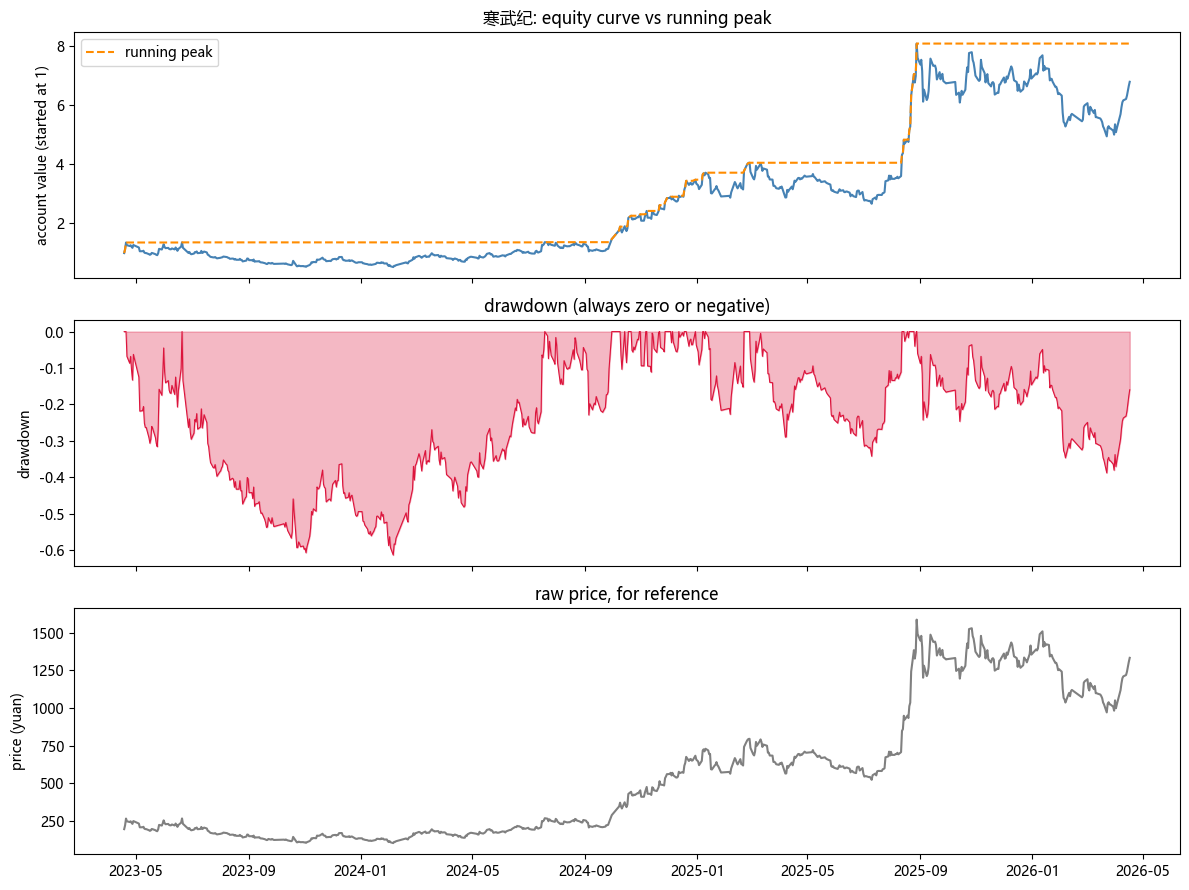

Max drawdown: -61.4%
Date of worst drawdown: 2024-02-05


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from utils import load_or_fetch
from plot_setup import setup_chinese_font

setup_chinese_font()

# Load 寒武纪 from your cache. This is one of your 10 stocks from Session 1.
df = load_or_fetch('sh.688256', '2023-04-17', '2026-04-17', cache_dir='data/prices/')

# Simple returns, not log. For equity curves we need simple.
returns = df['close'].pct_change().dropna()

# Three lines that are the entire drawdown calculation.
equity = (1 + returns).cumprod()          # if you had put 1 yuan in at the start
running_peak = equity.cummax()             # the highest the account ever reached, as of each day
drawdown = (equity - running_peak) / running_peak   # how far below the peak you are, on each day

# Plot all three so you can see what's happening.
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(equity.index, equity.values, color='steelblue')
axes[0].plot(running_peak.index, running_peak.values, color='darkorange', linestyle='--', label='running peak')
axes[0].set_ylabel('account value (started at 1)')
axes[0].set_title('寒武纪: equity curve vs running peak')
axes[0].legend()

axes[1].fill_between(drawdown.index, drawdown.values, 0, color='crimson', alpha=0.3)
axes[1].plot(drawdown.index, drawdown.values, color='crimson', linewidth=0.8)
axes[1].set_ylabel('drawdown')
axes[1].set_title('drawdown (always zero or negative)')

axes[2].plot(df.index[1:], df['close'].iloc[1:].values, color='gray')
axes[2].set_ylabel('price (yuan)')
axes[2].set_title('raw price, for reference')

plt.tight_layout()
plt.show()

# Print the headline number.
print(f"Max drawdown: {drawdown.min():.1%}")
print(f"Date of worst drawdown: {drawdown.idxmin().date()}")

In [2]:
# Your 10 stocks from Session 1.
codes = {
    'sh.601211': '国泰君安',
    'sh.601995': '中金公司',
    'sh.688256': '寒武纪',
    'sz.000876': '新希望',
    'sh.600522': '中天科技',
    'sz.300348': '长亮科技',
    'sz.002020': '京新药业',
    'sh.600761': '安徽合力',
    'sh.688433': '华曙高科',
    'sz.000848': '承德露露',
}

basket_labels = {
    'sh.601211': 'HS300', 'sh.601995': 'HS300', 'sh.688256': 'HS300',
    'sz.000876': 'HS300', 'sh.600522': 'HS300',
    'sz.300348': 'ZZ1000', 'sz.002020': 'ZZ1000', 'sh.600761': 'ZZ1000',
    'sh.688433': 'ZZ1000', 'sz.000848': 'ZZ1000',
}

# Compute max drawdown for each stock.
results = []
for code, name in codes.items():
    df = load_or_fetch(code, '2023-04-17', '2026-04-17', cache_dir='data/prices/')
    returns = df['close'].pct_change().dropna()
    equity = (1 + returns).cumprod()
    running_peak = equity.cummax()
    drawdown = (equity - running_peak) / running_peak
    
    results.append({
        'code': code,
        'name': name,
        'basket': basket_labels[code],
        'max_dd': drawdown.min(),
        'trough_date': drawdown.idxmin().date(),
    })

# Turn into a DataFrame and sort worst-first.
dd_table = pd.DataFrame(results).sort_values('max_dd')
dd_table['max_dd'] = dd_table['max_dd'].apply(lambda x: f"{x:.1%}")
print(dd_table.to_string(index=False))

     code name basket max_dd trough_date
sh.688433 华曙高科 ZZ1000 -66.0%  2024-09-23
sh.688256  寒武纪  HS300 -61.4%  2024-02-05
sz.300348 长亮科技 ZZ1000 -54.4%  2024-02-05
sz.002020 京新药业 ZZ1000 -45.6%  2024-02-05
sh.600761 安徽合力 ZZ1000 -44.4%  2025-04-08
sh.601995 中金公司  HS300 -42.4%  2024-07-08
sz.000876  新希望  HS300 -40.0%  2024-02-05
sh.600522 中天科技  HS300 -35.1%  2024-02-05
sz.000848 承德露露 ZZ1000 -28.6%  2026-03-23
sh.601211 国泰君安  HS300 -28.2%  2025-04-07


HS300 basket max drawdown:  -32.6% on 2024-02-05
ZZ1000 basket max drawdown: -32.2% on 2024-02-05


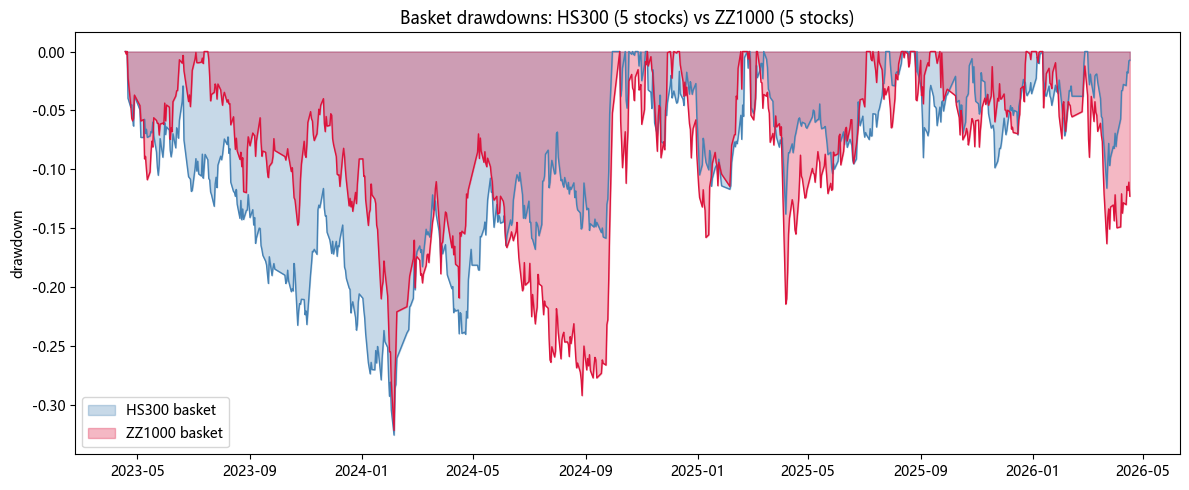

In [3]:
# Load all 10 stocks into a dict of closing price series.
closes = {}
for code in codes:
    df = load_or_fetch(code, '2023-04-17', '2026-04-17', cache_dir='data/prices/')
    closes[code] = df['close']

closes_df = pd.DataFrame(closes)

# Split by basket.
hs300_codes = [c for c, b in basket_labels.items() if b == 'HS300']
zz1000_codes = [c for c, b in basket_labels.items() if b == 'ZZ1000']

# Equal-weighted basket returns: compute each stock's simple return, then average across stocks per day.
hs300_returns = closes_df[hs300_codes].pct_change().mean(axis=1).dropna()
zz1000_returns = closes_df[zz1000_codes].pct_change().mean(axis=1).dropna()

# Drawdown function as a helper so we don't repeat ourselves.
def compute_drawdown(returns):
    equity = (1 + returns).cumprod()
    running_peak = equity.cummax()
    drawdown = (equity - running_peak) / running_peak
    return drawdown, equity, running_peak

hs300_dd, hs300_eq, hs300_peak = compute_drawdown(hs300_returns)
zz1000_dd, zz1000_eq, zz1000_peak = compute_drawdown(zz1000_returns)

# Print the headline numbers.
print(f"HS300 basket max drawdown:  {hs300_dd.min():.1%} on {hs300_dd.idxmin().date()}")
print(f"ZZ1000 basket max drawdown: {zz1000_dd.min():.1%} on {zz1000_dd.idxmin().date()}")

# Plot both drawdown curves on the same axes for direct comparison.
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(hs300_dd.index, hs300_dd.values, 0, color='steelblue', alpha=0.3, label='HS300 basket')
ax.fill_between(zz1000_dd.index, zz1000_dd.values, 0, color='crimson', alpha=0.3, label='ZZ1000 basket')
ax.plot(hs300_dd.index, hs300_dd.values, color='steelblue', linewidth=1)
ax.plot(zz1000_dd.index, zz1000_dd.values, color='crimson', linewidth=1)
ax.set_ylabel('drawdown')
ax.set_title('Basket drawdowns: HS300 (5 stocks) vs ZZ1000 (5 stocks)')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
def drawdown_details(returns):
    """Return max drawdown plus peak date, trough date, recovery date, and durations in trading days."""
    equity = (1 + returns).cumprod()
    running_peak = equity.cummax()
    drawdown = (equity - running_peak) / running_peak
    
    # Trough: the day of the worst drawdown.
    trough_date = drawdown.idxmin()
    max_dd = drawdown.min()
    
    # Peak: the last day before the trough when the running peak was set.
    # Everything from the peak onwards was underwater until the recovery.
    peak_date = running_peak.loc[:trough_date].idxmax()
    
    # Recovery: the first day after the trough when the equity curve got back to the old peak.
    # If it never recovered, this is None.
    peak_value = equity.loc[peak_date]
    after_trough = equity.loc[trough_date:]
    recovery_mask = after_trough >= peak_value
    if recovery_mask.any():
        recovery_date = after_trough[recovery_mask].index[0]
    else:
        recovery_date = None
    
    # Durations in trading days (count of index positions in each slice).
    peak_to_trough = equity.loc[peak_date:trough_date].shape[0] - 1
    if recovery_date is not None:
        trough_to_recovery = equity.loc[trough_date:recovery_date].shape[0] - 1
        total_underwater = peak_to_trough + trough_to_recovery
    else:
        trough_to_recovery = None
        total_underwater = None
    
    return {
        'max_dd': max_dd,
        'peak_date': peak_date.date(),
        'trough_date': trough_date.date(),
        'recovery_date': recovery_date.date() if recovery_date is not None else None,
        'peak_to_trough_days': peak_to_trough,
        'trough_to_recovery_days': trough_to_recovery,
        'total_underwater_days': total_underwater,
    }

# Run it on all 10 stocks.
duration_results = []
for code, name in codes.items():
    df = load_or_fetch(code, '2023-04-17', '2026-04-17', cache_dir='data/prices/')
    returns = df['close'].pct_change().dropna()
    d = drawdown_details(returns)
    d['code'] = code
    d['name'] = name
    d['basket'] = basket_labels[code]
    duration_results.append(d)

dur_table = pd.DataFrame(duration_results)
dur_table = dur_table[['name', 'basket', 'max_dd', 'peak_date', 'trough_date', 'recovery_date',
                       'peak_to_trough_days', 'trough_to_recovery_days', 'total_underwater_days']]
dur_table = dur_table.sort_values('max_dd')
dur_table['max_dd'] = dur_table['max_dd'].apply(lambda x: f"{x:.1%}")
print(dur_table.to_string(index=False))

# Also do the two baskets.
print("\n--- Baskets ---")
for name, ret in [('HS300', hs300_returns), ('ZZ1000', zz1000_returns)]:
    d = drawdown_details(ret)
    recovery_str = str(d['recovery_date']) if d['recovery_date'] else 'not yet'
    underwater_str = f"{d['total_underwater_days']} days" if d['total_underwater_days'] else 'ongoing'
    print(f"{name} basket: {d['max_dd']:.1%}, peak {d['peak_date']}, trough {d['trough_date']}, "
          f"recovered {recovery_str}, underwater {underwater_str}")

name basket max_dd  peak_date trough_date recovery_date  peak_to_trough_days  trough_to_recovery_days  total_underwater_days
华曙高科 ZZ1000 -66.0% 2023-07-17  2024-09-23    2025-02-21                  289                     97.0                  386.0
 寒武纪  HS300 -61.4% 2023-06-20  2024-02-05    2024-07-19                  155                    107.0                  262.0
长亮科技 ZZ1000 -54.4% 2023-04-20  2024-02-05    2024-10-08                  195                    157.0                  352.0
京新药业 ZZ1000 -45.6% 2023-05-29  2024-02-05    2025-07-08                  171                    340.0                  511.0
安徽合力 ZZ1000 -44.4% 2024-05-10  2025-04-08          None                  221                      NaN                    NaN
中金公司  HS300 -42.4% 2023-05-09  2024-07-08          None                  283                      NaN                    NaN
 新希望  HS300 -40.0% 2023-04-19  2024-02-05          None                  196                      NaN                    NaN


In [5]:
# Load the four index price series you already cached in Session 1.
index_codes = {
    'sh.000016': '上证50',
    'sh.000300': '沪深300',
    'sh.000852': '中证1000',
    'sz.399006': '创业板指',
}

index_results = []
for code, name in index_codes.items():
    df = load_or_fetch(code, '2023-04-17', '2026-04-17', cache_dir='data/prices/')
    returns = df['close'].pct_change().dropna()
    d = drawdown_details(returns)
    d['name'] = name
    index_results.append(d)

idx_table = pd.DataFrame(index_results)
idx_table = idx_table[['name', 'max_dd', 'peak_date', 'trough_date', 'recovery_date',
                       'peak_to_trough_days', 'trough_to_recovery_days', 'total_underwater_days']]
idx_table['max_dd'] = idx_table['max_dd'].apply(lambda x: f"{x:.1%}")
print("--- Actual index drawdowns ---")
print(idx_table.to_string(index=False))

print("\n--- Your 5-stock baskets for comparison ---")
print(f"HS300 basket (5 stocks):  -32.6%, underwater 351 days")
print(f"ZZ1000 basket (5 stocks): -32.2%, underwater 295 days")

--- Actual index drawdowns ---
  name max_dd  peak_date trough_date recovery_date  peak_to_trough_days  trough_to_recovery_days  total_underwater_days
  上证50 -19.9% 2023-04-18  2024-01-17    2024-09-30                  184                      169                    353
 沪深300 -24.1% 2023-04-18  2024-09-13    2024-10-08                  344                       10                    354
中证1000 -38.6% 2023-04-18  2024-02-05    2025-08-13                  197                      366                    563
  创业板指 -37.0% 2023-04-18  2024-09-23    2024-10-08                  348                        6                    354

--- Your 5-stock baskets for comparison ---
HS300 basket (5 stocks):  -32.6%, underwater 351 days
ZZ1000 basket (5 stocks): -32.2%, underwater 295 days
